In [1]:
### 1. Missing Complete at Random (MCAR):
# Missing Completely at random there is no reason for why that data is missing  

### 2. Missing at Random (MAR):
# There is some reason for that data is missing - e.g some peoples are not comfortable to disclose the salary and age, older people may skip the online questionaries like older people will skip height, Cholesterol those kind of questions
# the missing is depends on other observed variables. 

### 3. Missing not at Random
# The missing depends on missing value itself - e.g High income people hide their income

In [2]:
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# one way - delete the rows or data points to handle missing values

df.shape

(891, 15)

In [8]:
df.dropna().shape

(182, 15)

In [10]:
# deleting is not an feasible method, we will loose huge amount of data 

# column wise deletion if particular column has large amount of null value 

df.dropna(axis=1), # add inplace = True to make the changes permanent

(     survived  pclass     sex  sibsp  parch     fare   class    who  \
 0           0       3    male      1      0   7.2500   Third    man   
 1           1       1  female      1      0  71.2833   First  woman   
 2           1       3  female      0      0   7.9250   Third  woman   
 3           1       1  female      1      0  53.1000   First  woman   
 4           0       3    male      0      0   8.0500   Third    man   
 ..        ...     ...     ...    ...    ...      ...     ...    ...   
 886         0       2    male      0      0  13.0000  Second    man   
 887         1       1  female      0      0  30.0000   First  woman   
 888         0       3  female      1      2  23.4500   Third  woman   
 889         1       1    male      0      0  30.0000   First    man   
 890         0       3    male      0      0   7.7500   Third    man   
 
      adult_male alive  alone  
 0          True    no  False  
 1         False   yes  False  
 2         False   yes   True  
 3    

## Imputation Missing Values

#### 1. Mean Value Imputation - Works well with normal distributed data

<Axes: xlabel='age', ylabel='Count'>

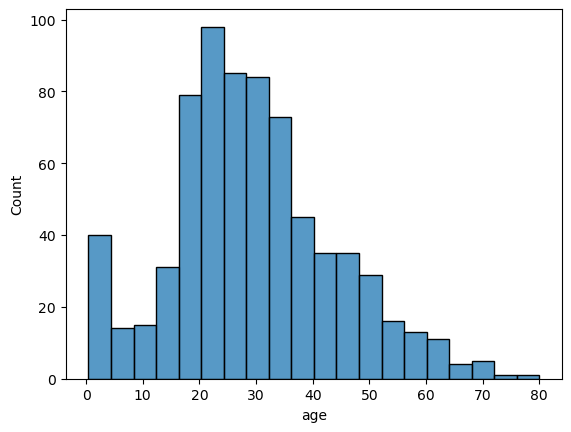

In [11]:
sns.histplot(df['age'])

<Axes: xlabel='age', ylabel='Count'>

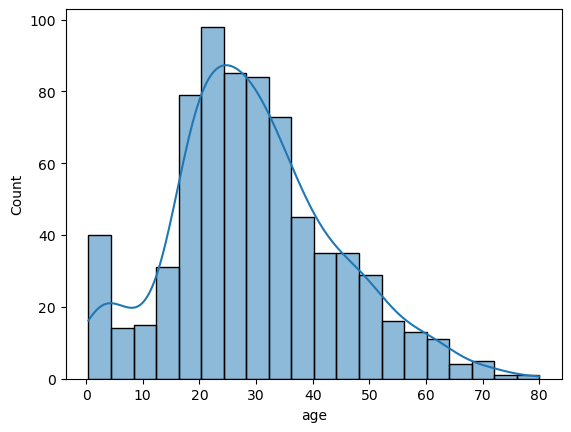

In [12]:
sns.histplot(df['age'], kde = True)

In [13]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [14]:
df['age_mean'] = df['age'].fillna(df['age'].mean())

In [15]:
df['age_mean']

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age_mean, Length: 891, dtype: float64

In [16]:
df[['age_mean', 'age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


### 2. Median Imputation - Works well when outliers presents in data (left or right skewed)

In [17]:
df['age_median'] = df['age'].fillna(df['age'].median())

In [28]:
df[['age_median', 'age_mean', 'age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode Imputation - For categorical values

In [21]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [22]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [32]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [33]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [34]:
df['embarked_mode'].isnull().sum()

np.int64(0)

In [36]:
df['embarked'].isnull().sum()

np.int64(2)